9. This question involves the use of multiple linear regression on the
Auto data set.
(a) Produce a scatterplot matrix which includes all of the variables
in the data set.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("Auto.csv")
# excluding "name"
num = data.drop(columns=["name"])
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


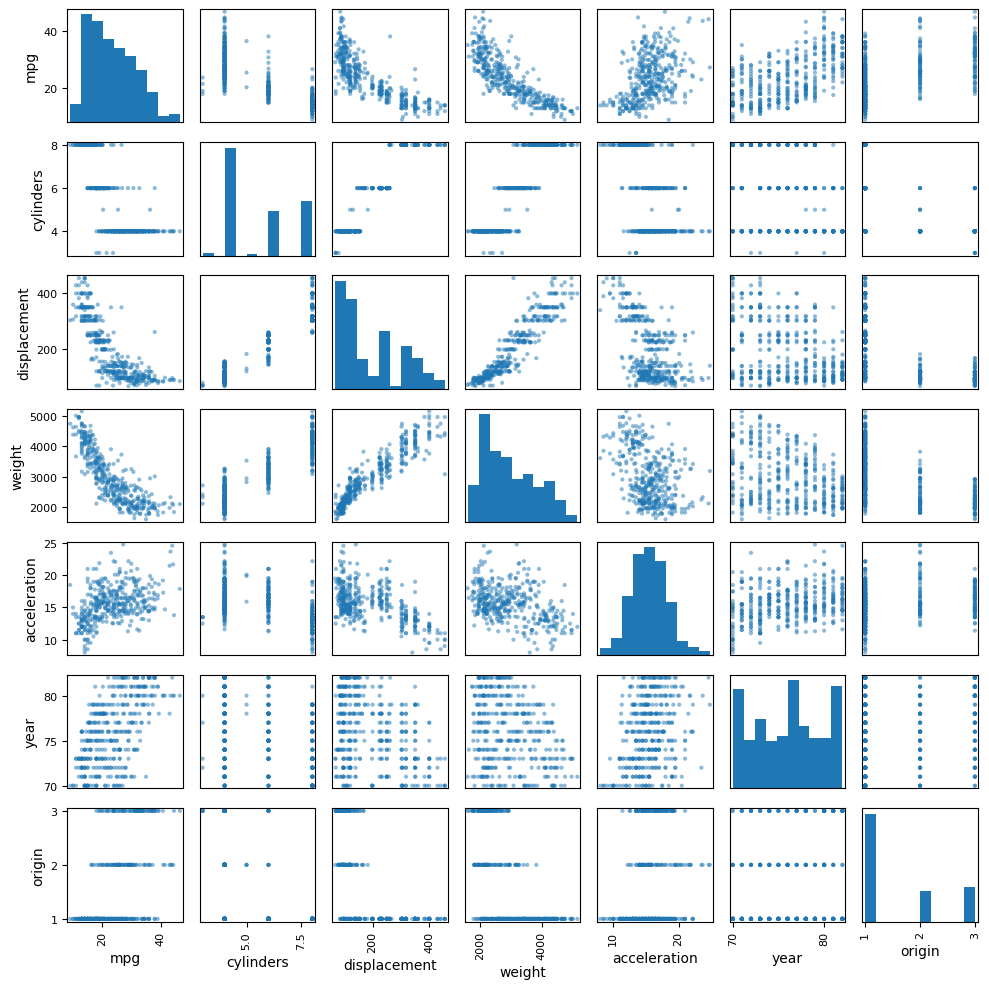

In [14]:
from pandas.plotting import scatter_matrix

scatter_matrix(num, figsize=(10,10), diagonal="hist")
plt.tight_layout(); plt.show()


(b) Compute the matrix of correlations between the variables using
the DataFrame.corr() method.

In [18]:
corr = num.corr(numeric_only=True)
print(corr)


                   mpg  cylinders  displacement    weight  acceleration  \
mpg           1.000000  -0.776260     -0.804443 -0.831739      0.422297   
cylinders    -0.776260   1.000000      0.950920  0.897017     -0.504061   
displacement -0.804443   0.950920      1.000000  0.933104     -0.544162   
weight       -0.831739   0.897017      0.933104  1.000000     -0.419502   
acceleration  0.422297  -0.504061     -0.544162 -0.419502      1.000000   
year          0.581469  -0.346717     -0.369804 -0.307900      0.282901   
origin        0.563698  -0.564972     -0.610664 -0.581265      0.210084   

                  year    origin  
mpg           0.581469  0.563698  
cylinders    -0.346717 -0.564972  
displacement -0.369804 -0.610664  
weight       -0.307900 -0.581265  
acceleration  0.282901  0.210084  
year          1.000000  0.184314  
origin        0.184314  1.000000  


(c) Use the sm.OLS() function to perform a multiple linear regression
with mpg as the response and all other variables except name as
the predictors. Use the summarize() function to print the results.
Comment on the output.

In [21]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

auto = pd.read_csv("Auto.csv")
auto["horsepower"] = pd.to_numeric(auto["horsepower"], errors="coerce")

auto = auto.dropna().reset_index(drop=True)


y = num["mpg"].astype(float).to_numpy()
X = num.drop(columns=["mpg"]).astype(float)
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          2.04e-139
Time:                        17:42:44   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.2184      4.644     -3.707   

i. Is there a relationship between the predictors and the re-sponse? Use the anova_lm() function from statsmodels to
answer this question.

The overall F-statistic is 252.4 with p ≈ 2.0×10⁻¹³⁹, indicating a highly significant linear relationship between the predictors and mpg.

ii. Which predictors appear to have a statistically significant
relationship to the response?


Significant: displacement (positive, p=0.008), weight (negative, p<0.001), year (positive, p<0.001), origin (positive, p<0.001).

Not significant: cylinders (p=0.128), horsepower (p=0.220), acceleration (p=0.415).

iii. What does the coefficient for the year variable suggest?

The coefficient year = 0.7508 means that, holding other variables constant, each additional model year increases mpg by about 0.75 on average—newer cars tend to be more fuel-efficient.

(d) Produce some of diagnostic plots of the linear regression fit as
described in the lab. Comment on any problems you see with the
fit. Do the residual plots suggest any unusually large outliers?
Does the leverage plot identify any observations with unusually
high leverage?

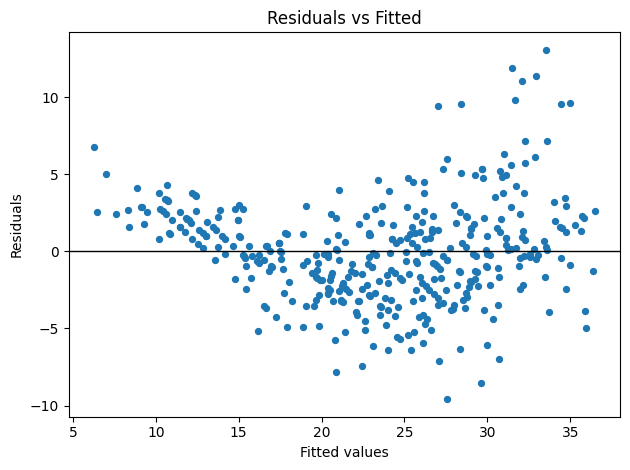

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

fitted = model.fittedvalues
resid = model.resid
influence = model.get_influence()
stud_resid = influence.resid_studentized_internal

# Residuals vs Fitted
plt.figure()
plt.scatter(fitted, resid, s=18)
plt.axhline(0, color='k', linewidth=1)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.tight_layout(); plt.show()

A slight fan shape/curvature at higher fitted values

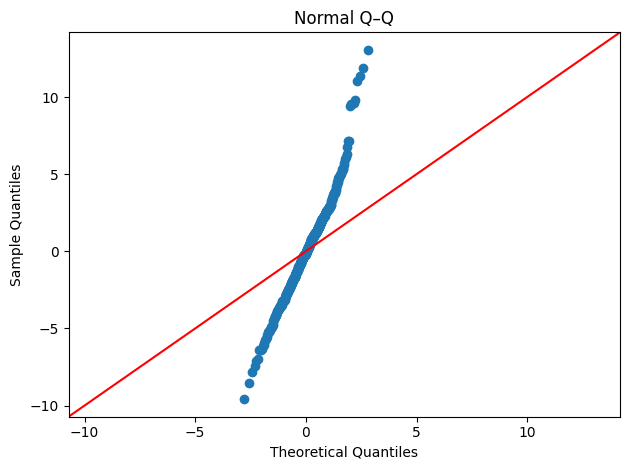

In [31]:
# Normal Q–Q
sm.qqplot(resid, line='45')
plt.title("Normal Q–Q")
plt.tight_layout(); plt.show()



Tails deviate from the 45° line, indicating residuals are not perfectly normal.

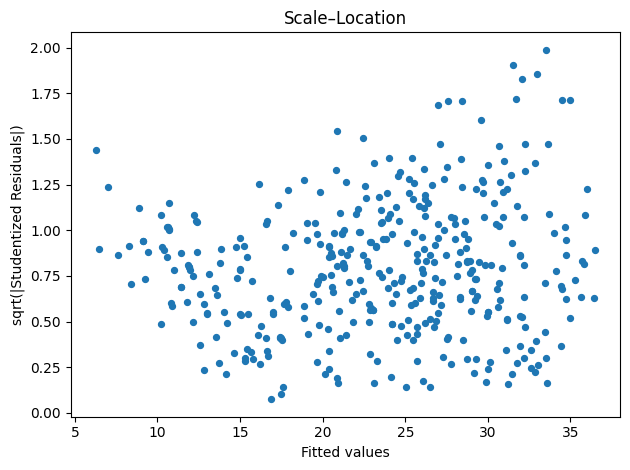

In [33]:
# Scale–Location
plt.figure()
plt.scatter(fitted, np.sqrt(np.abs(stud_resid)), s=18)
plt.xlabel("Fitted values")
plt.ylabel("sqrt(|Studentized Residuals|)")
plt.title("Scale–Location")
plt.tight_layout(); plt.show()

The spread of residuals increases with fitted values, supporting the heteroskedasticity observation.

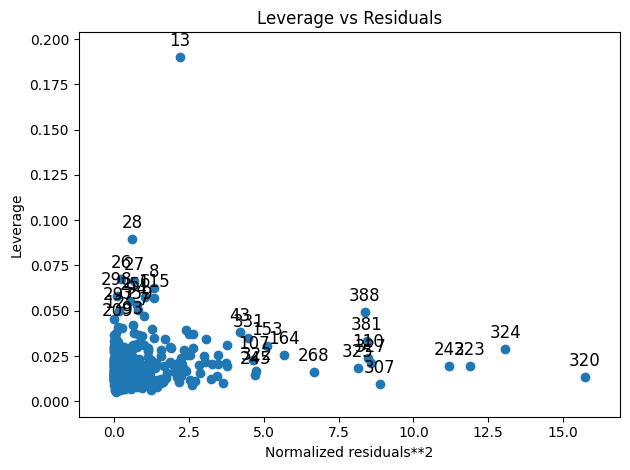

In [34]:
# Leverage vs. Residuals (Studentized)
sm.graphics.plot_leverage_resid2(model)
plt.title("Leverage vs Residuals")
plt.tight_layout(); plt.show()

A few high-leverage/influential points are present (worth further inspection as flagged in the plot).

(e) Fit some models with interactions as described in the lab. Do
any interactions appear to be statistically significant?

In [36]:
import statsmodels.formula.api as smf

m_int = smf.ols('mpg ~ cylinders*horsepower + weight*year + displacement + acceleration + origin', data=auto).fit()
print(m_int.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     277.7
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          1.29e-161
Time:                        18:02:24   Log-Likelihood:                -965.15
No. Observations:                 392   AIC:                             1950.
Df Residuals:                     382   BIC:                             1990.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept              -46.5523 

With cylinders:horsepower and weight:year, r^2 has increased. both interactions significant: hp’s negative effect on mpg weakens with more cylinders, and weight’s negative effect is stronger for newer cars; significant mains: cylinders, horsepower, weight, year, origin.

(f) Try a few different transformations of the variables, such as
log(X), √X, X2. Comment on your findings.

In [37]:
# log(horsepower)
m_log = smf.ols('mpg ~ cylinders + displacement + np.log(horsepower) + weight + acceleration + year + origin', data=auto).fit()
print(m_log.summary())

# sqrt(weight)
m_sqrt = smf.ols('mpg ~ cylinders + displacement + horsepower + np.sqrt(weight) + acceleration + year + origin', data=auto).fit()
print(m_sqrt.summary())

# weight^2
auto["weight_sq"] = auto["weight"]**2
m_sq = smf.ols('mpg ~ cylinders + displacement + horsepower + weight + weight_sq + acceleration + year + origin', data=auto).fit()
print(m_sq.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     281.6
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          5.80e-147
Time:                        18:08:43   Log-Likelihood:                -1005.7
No. Observations:                 392   AIC:                             2027.
Df Residuals:                     384   BIC:                             2059.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             27.2540      8

√weight model: clear improvement vs baseline (adj. R² ≈ 0.853); residuals look a bit smoother.

Quadratic (weight + weight²): also improves; weight < 0, weight_sq > 0 ⇒ diminishing negative effect of weight on mpg.